# 1.4 - Visualisation : Matplotlib puis Seaborn

**Navigation** : [<< 1.3 Pandas](1.3-Analyse_de_Donnees_avec_Pandas.ipynb) | [Index](../README.md) | [>> 1.5 Exploration](1.5-Exploration_Nettoyage_Donnees_Reelles.ipynb)

**Durée indicative** : ~60 min.

**Jeu de données** : mesures de manchots de la station Palmer (Antarctique) — 344 individus, 3 espèces, vraies données de terrain avec valeurs manquantes (provenance et licence : `data/PROVENANCE.md`).


## Objectifs d'apprentissage

1. Construire une figure **matplotlib** (figure, axes, titre, légende) et savoir la lire.
2. **Choisir le graphique selon la question posée** : distribution, comparaison de groupes, relation, composition.
3. Reconnaître et corriger les **erreurs classiques** : axe tronqué, surcharge, camembert de trop de catégories.
4. Passer à **seaborn** : la même information en moins de code, avec l'encodage visuel (`hue`) automatisé.
5. Produire une figure **lisible** : titres, unités dans les libellés, source des données.

## Pourquoi la visualisation d'abord

Avant tout modèle, l'œil voit ce que les statistiques mettent dix lignes à formuler : un groupe à part, une relation qui n'est pas linéaire, une valeur impossible. **matplotlib est l'organe** — il dessine tout, du nuage de points à la carte — et **seaborn est une couche statistique par-dessus** : il sait « un nuage coloré par espèce », « une distribution par groupe » en une ligne. Le reste de la formation (2.x, labs agents) suppose que vous lisez ces figures sans effort ; ce notebook installe ce réflexe.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Le jeu de donnees reel : manchots de la station Palmer (19 valeurs manquantes conservees)
manchots = pd.read_csv("../data/penguins.csv")
manchots.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 1. Le canvas matplotlib : figure et axes

Toute figure matplotlib suit le même schéma : une **figure** (la toile) contient des **axes** (un système de coordonnées). `plt.subplots()` rend les deux. On dessine *dans* les axes (`ax.scatter`), on annote la figure (`ax.set_title`, `ax.set_xlabel`), et la cellule de notebook affiche le résultat. Le réflexe à prendre tout de suite : **chaque axe porte son unité** (`masse (g)` et non `masse`) — une figure non annotée n'est pas une figure.


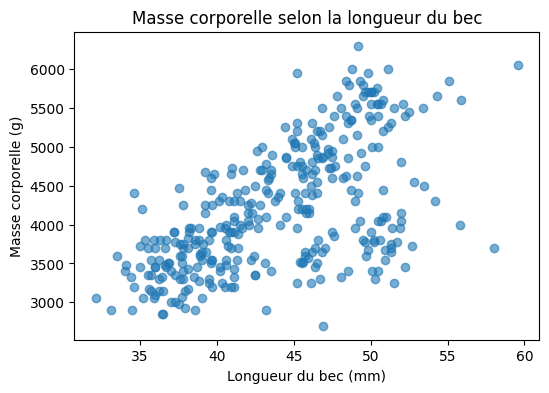

In [2]:
# Le nuage de points le plus simple possible : longueur du bec vs masse corporelle
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(manchots["bill_length_mm"], manchots["body_mass_g"], alpha=0.6)
ax.set_title("Masse corporelle selon la longueur du bec")
ax.set_xlabel("Longueur du bec (mm)")
ax.set_ylabel("Masse corporelle (g)")
plt.show()


**Lecture du rendu.** Chaque point est un manchot : son bec en abscisse, sa masse en ordonnée. Deux choses sautent aux yeux — la relation montanteglobale (bec plus long, masse plus élevée), et les **trois bandes verticales** : le nuage n'est pas homogène, il est structuré en groupes. C'est exactement le genre de structure que la couleur par espèce va confirmer — et c'est la raison pour laquelle on visualise *avant* de modéliser.


## 2. La question choisit le graphique

Le graphique n'est pas un décor : il répond à une question. Quatre questions couvrent 90 % des besoins d'exploration :

| Question posée | Graphique | Geste matplotlib |
|---|---|---|
| « Comment se distribue cette variable ? » | **histogramme** | `ax.hist(colonne)` |
| « Ces groupes diffèrent-ils ? » | **boîte à moustaches** | `ax.boxplot([groupe_a, groupe_b, ...])` |
| « Ces deux variables sont-elles liées ? » | **nuage de points** | `ax.scatter(x, y)` |
| « Quelle est la composition / les effectifs ? » | **barres** (baseline 0) | `ax.bar(categories, effectifs)` |


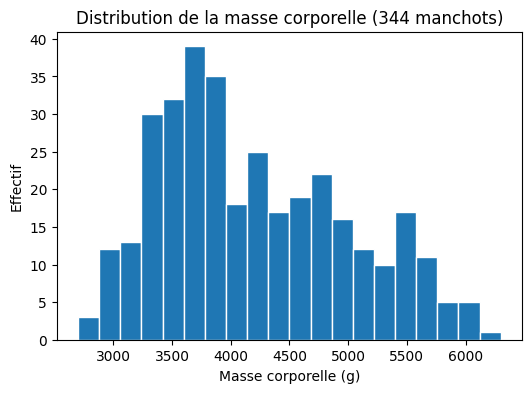

In [3]:
# Distribution : histogramme des masses corporelles
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(manchots["body_mass_g"].dropna(), bins=20, edgecolor="white")
ax.set_title("Distribution de la masse corporelle (344 manchots)")
ax.set_xlabel("Masse corporelle (g)")
ax.set_ylabel("Effectif")
plt.show()


**Lecture.** L'histogramme découpe l'axe des masses en 20 bandes et compte les individus par bande. Le profil est ** multimodal** — plusieurs bosses — alors qu'une seule population donnerait une cloche unique. Chaque bosse est ici l'empreinte d'une espèce (et d'un sexe) : l'histogramme d'une variable mélangée raconte le mélange.


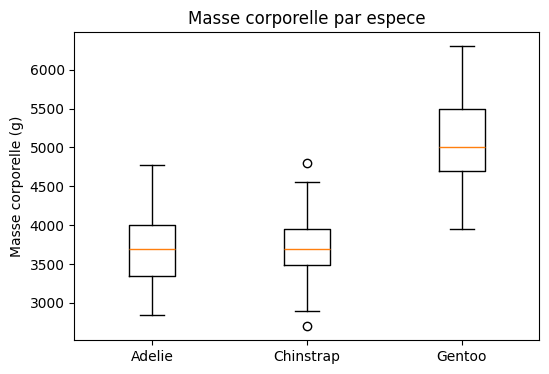

In [4]:
# Comparaison de groupes : boites a moustaches de la masse par espece
groupes = [manchots.loc[manchots["species"] == s, "body_mass_g"].dropna()
           for s in ["Adelie", "Chinstrap", "Gentoo"]]

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(groupes, tick_labels=["Adelie", "Chinstrap", "Gentoo"])
ax.set_title("Masse corporelle par espece")
ax.set_ylabel("Masse corporelle (g)")
plt.show()


**Lecture.** Chaque boîte résume un groupe : la boîte centrale (quartiles 1 à 3, 50 % des individus), la barre médiane, les moustaches (l'étendue des valeurs hors valeurs extrêmes), et les points isolés au-delà. La lecture est immédiate : **Gentoo est nettement plus lourd**, Adelie et Chinstrap se recouvrent presque. La boîte à moustaches est l'outil de la question « ces groupes diffèrent-ils ? » — sans hypothèse, sans calcul.


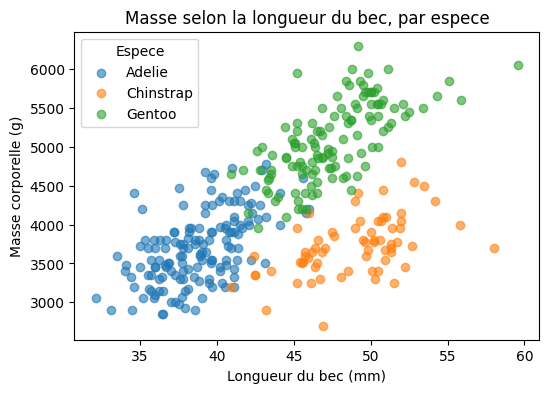

In [5]:
# Relation : le meme nuage, colore par espece — la structure en bandes se decoupe
couleurs = {"Adelie": "tab:blue", "Chinstrap": "tab:orange", "Gentoo": "tab:green"}

fig, ax = plt.subplots(figsize=(6, 4))
for espece, couleur in couleurs.items():
    sous = manchots[manchots["species"] == espece]
    ax.scatter(sous["bill_length_mm"], sous["body_mass_g"],
               alpha=0.6, label=espece, color=couleur)
ax.set_title("Masse selon la longueur du bec, par espece")
ax.set_xlabel("Longueur du bec (mm)")
ax.set_ylabel("Masse corporelle (g)")
ax.legend(title="Espece")
plt.show()


**Lecture.** La couleur transforme la lecture : ce que l'œil voyait comme « trois bandes verticales » devient **trois nuages**, chacun resserré sur sa propre droite. La relation bec-masse existe *à l'intérieur* de chaque espèce — mais les niveaux diffèrent. Une conclusion provisoire, à toute hypothèse prématurée : la composition du mélange (quelle espèce est dans l'échantillon) change la relation observée. Le notebook 1.6 y revient en statistique, avec la corrélation.


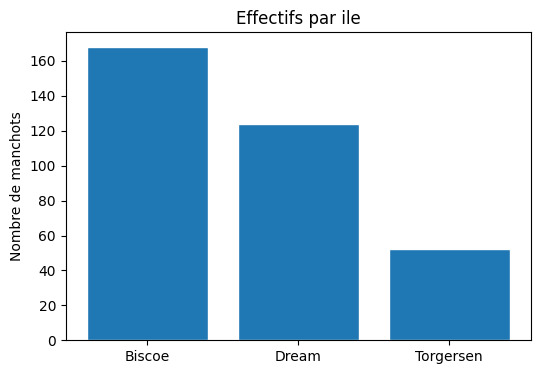

In [6]:
# Composition : effectifs par ile (barres, baseline a zero)
effectifs_iles = manchots["island"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(effectifs_iles.index, effectifs_iles.values, edgecolor="white")
ax.set_title("Effectifs par ile")
ax.set_ylabel("Nombre de manchots")
plt.show()


**Lecture.** Biscoe domine nettement l'échantillon. Deux mises en garde durables sur les barres : elles **commencent toujours à zéro** (la longueur encode la quantité — voir la section 3), et elles répondent « combien », jamais « à quel point les groupes diffèrent » (c'est le travail de la boîte ou du nuage).


## 3. Les erreurs classiques

Deux erreurs reviennent dans tous les rapports. **L'axe tronqué** : zoomer l'axe des y entre 4000 et 4600 g transforme une différence de 10 % en « écart énorme ». **La surcharge** : superposer des dizaines de courbes rend la figure illisible, donc inutile. Voici les deux, commises exprès puis corrigées.


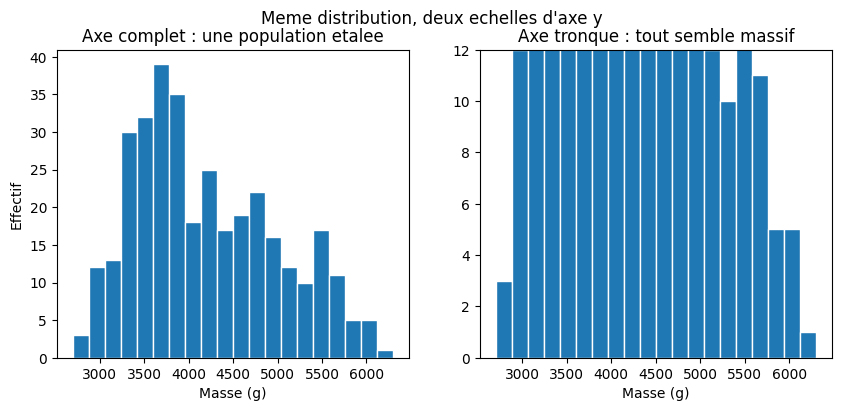

In [7]:
# Erreur 1 : axe tronque — le MEME histogramme, deux echelles
masses = manchots["body_mass_g"].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
fig.suptitle("Meme distribution, deux echelles d'axe y")

ax1.hist(masses, bins=20, edgecolor="white")
ax1.set_title("Axe complet : une population etalee")
ax1.set_xlabel("Masse (g)"); ax1.set_ylabel("Effectif")

ax2.hist(masses, bins=20, edgecolor="white")
ax2.set_ylim(0, 12)                           # la troncature : bande etroite d'effectifs
ax2.set_title("Axe tronque : tout semble massif")
ax2.set_xlabel("Masse (g)")

plt.show()


**Lecture.** Aucune donnée n'a changé — seule l'échelle de droite a été resserrée sur la bande 0-12 individus. Les 14 bandes les plus peuplées (jusqu'à 39 manchots) sont sorties du cadre ; les six bandes les moins peuplées remplissent la figure, et des écarts de 2-3 individus ressemblent à des contrastes massifs. L'œil compare des longueurs de barres, pas des valeurs : un axe tronqué peut suggérer n'importe quoi. **Règle : histogrammes et barres partent de zéro, toujours.** (Le zoom est légitime sur un nuage de points ou une courbe — l'objet y est la *forme*, pas la longueur des barres.)


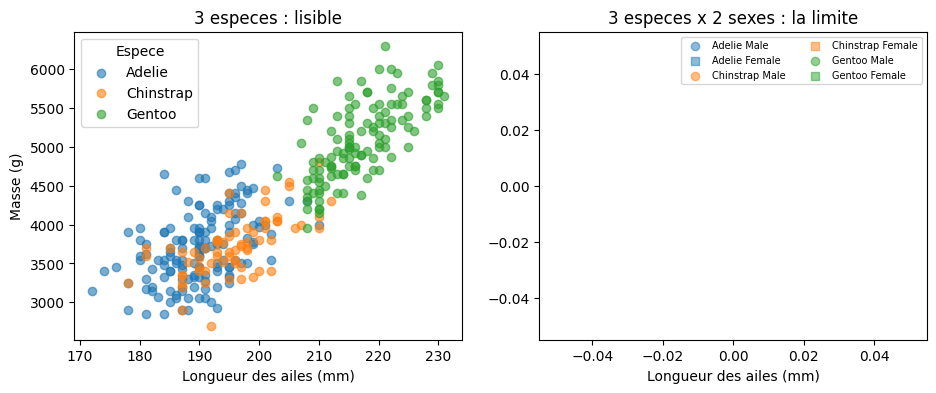

In [8]:
# Erreur 2 : surcharge — 3 especes lisibles vs 3 couleurs x 3 iles empilees
sous = manchots.dropna(subset=["body_mass_g", "sex"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

for espece, couleur in couleurs.items():
    sous_e = sous[sous["species"] == espece]
    ax1.scatter(sous_e["flipper_length_mm"], sous_e["body_mass_g"],
                alpha=0.6, color=couleur, label=espece)
ax1.set_title("3 especes : lisible")
ax1.set_xlabel("Longueur des ailes (mm)"); ax1.set_ylabel("Masse (g)")
ax1.legend(title="Espece")

marqueurs = {"Male": "o", "Female": "s"}
for espece, couleur in couleurs.items():
    for sexe, marqueur in marqueurs.items():
        sous_g = sous[(sous["species"] == espece) & (sous["sex"] == sexe)]
        ax2.scatter(sous_g["flipper_length_mm"], sous_g["body_mass_g"],
                    alpha=0.5, color=couleur, marker=marqueur,
                    label=f"{espece} {sexe}")
ax2.set_title("3 especes x 2 sexes : la limite")
ax2.set_xlabel("Longueur des ailes (mm)")
ax2.legend(fontsize=7, ncol=2)

plt.show()


**Lecture.** À gauche, trois groupes se lisent d'un coup d'œil. À droite, la même donnée croisée par sexe — six catégories, six entrées de légende — et la figure devient du travail. La solution n'est jamais « plus de couleurs » : c'est **plusieurs figures simples**, ou un encodage multiplié (facettes, que seaborn fait nativement). Une figure doit répondre à UNE question.


## 4. Seaborn : la couche statistique

Seaborn dessine les mêmes figures mais **comprend les DataFrames** : on nomme les colonnes, il encode les couleurs, trace la légende et gère les styles. Le nuage coloré de la section 2 — neuf lignes de matplotlib — devient une ligne.


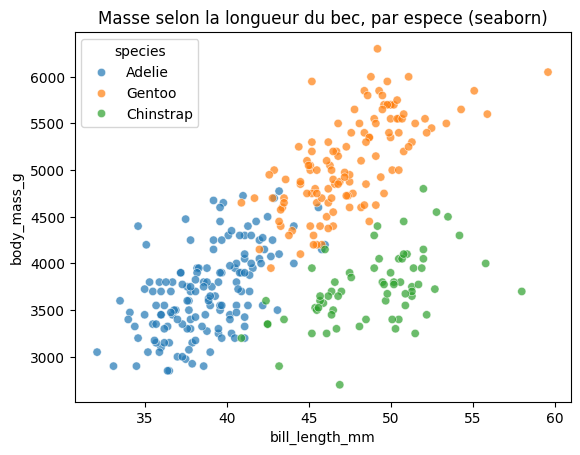

In [9]:
import seaborn as sns

# Le meme nuage, en une ligne : x, y, hue depuis le DataFrame
sns.scatterplot(data=manchots, x="bill_length_mm", y="body_mass_g",
                hue="species", alpha=0.7)
plt.title("Masse selon la longueur du bec, par espece (seaborn)")
plt.show()


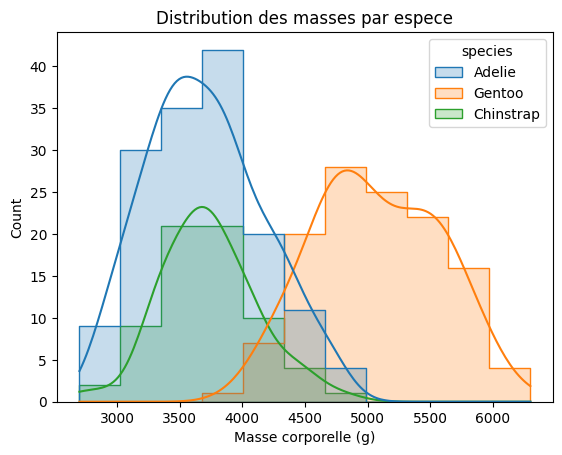

In [10]:
# Distribution par groupe : histogramme + densite lissageee
sns.histplot(data=manchots, x="body_mass_g", hue="species",
             kde=True, element="step", stat="count", common_norm=False)
plt.title("Distribution des masses par espece")
plt.xlabel("Masse corporelle (g)")
plt.show()


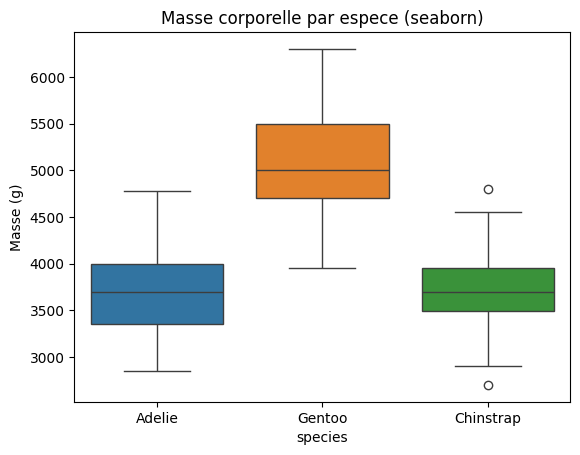

In [11]:
# Boite a moustaches par groupe, directement
sns.boxplot(data=manchots, x="species", y="body_mass_g", hue="species", legend=False)
plt.title("Masse corporelle par espece (seaborn)")
plt.ylabel("Masse (g)")
plt.show()


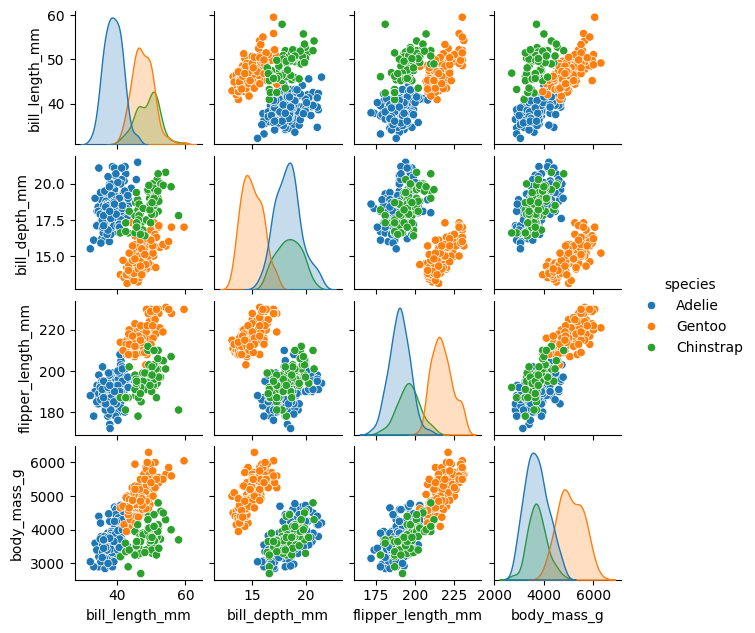

In [12]:
# La matrice de nuages : toutes les paires de variables numeriques d'un coup
sns.pairplot(manchots.drop(columns=["year"]), hue="species", height=1.6)
plt.show()


**Lecture.** La `pairplot` généralise le réflexe « nuage de points » : chaque case croise deux variables numériques, la diagonale montre la distribution de chacune. C'est l'outil de la **première rencontre** avec un jeu multivarié : en un regard, la Gentoo se sépare des deux autres sur presque toutes les mesures (ailes, bec, masse), tandis que la Chinstrap recouvre l'Adelie presque partout — sauf sur la longueur du bec.


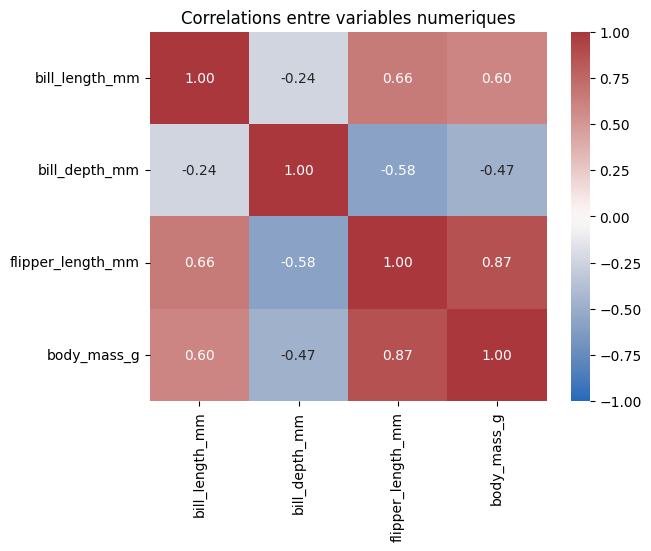

In [13]:
# Heatmap de correlation entre variables numeriques
corr = manchots.drop(columns=["year"]).corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1)
plt.title("Correlations entre variables numeriques")
plt.show()


**Lecture.** La heatmap résume chaque nuage de la `pairplot` en un coefficient : +1 rouge-bleu saturé = relation linéaire croissante parfaite, 0 = aucune relation *linéaire*. Ailes et masse : **+0.87**. Mais un coefficient élevé ne dit ni direction de cause ni absence de structure cachée — la longueur et la profondeur du bec sont corrélées négativement sur l'ensemble (−0.24) alors qu'elles sont corrélées positivement *au sein de chaque espèce* (de +0.39 à +0.65) — le mélange des espèces fabrique le signe. Corrélation n'est pas causalité : le notebook [1.6](1.6-Statistiques_Descriptives.ipynb) le démonte proprement.


## Exercices

Quatre exercices. Les cellules s'exécutent telles quelles (elles ne tracent encore rien d'utile) ; remplacez les `pass`/`None` en suivant les étapes.


### Exercice 1 : histogramme annoté — la longueur des ailes

Tracez l'histogramme de `flipper_length_mm` (20 bandes, contours blancs), avec titre et axes unités. Décrivez ensuite en une phrase la forme observée (modalité(s)) dans le commentaire final.


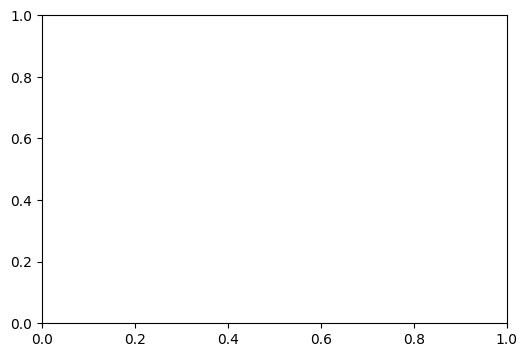

Exercice a completer


In [14]:
# Exercice 1 : histogramme de la longueur des ailes
fig, ax = plt.subplots(figsize=(6, 4))
# Etape 1: ax.hist sur manchots["flipper_length_mm"] avec bins=20, edgecolor="white"
pass  # TODO
# Etape 2: titre + libelles d'axes avec unites
pass  # TODO
plt.show()
print("Exercice a completer")


### Exercice 2 : le bon graphique pour la bonne question

Pour chaque question, choisissez le graphique (histogramme / boîte / nuage / barres) — puis tracez le second seulement : « la masse diffère-t-elle entre mâles et femelles ? » (variable `sex`).


In [15]:
# Exercice 2 : boites masse par sexe
# Etape 1: boites a moustaches de body_mass_g selon sex (matplotlib ou seaborn)
pass  # TODO
plt.show()
print("Exercice a completer")


Exercice a completer


### Exercice 3 : démasquer un axe tronqué

Reproduisez le geste de la section 3 sur les effectifs d'îles : barres avec `ax.set_ylim(0, ...)` complet d'un côté, puis tronqué de l'autre (`ax.set_ylim(140, 150)` par exemple). Commentez : que suggère faussement la version tronquée ?


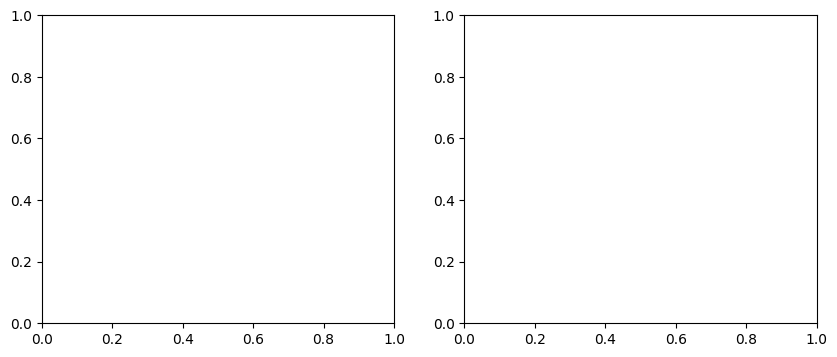

Exercice a completer


In [16]:
# Exercice 3 : barres d'effectifs, axe complet vs tronque
effectifs = manchots["island"].value_counts()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
# Etape 1: barres sur ax1 (baseline 0 implicite)
pass  # TODO
# Etape 2: memes barres sur ax2, puis ax2.set_ylim tronque
pass  # TODO
plt.show()
print("Exercice a completer")


### Exercice 4 : seaborn en une ligne — bec vs ailes par espèce

Tracez `bill_length_mm` (x) contre `flipper_length_mm` (y), coloré par `species`, avec seaborn. En une phrase de commentaire : la Chinstrap se distingue-t-elle mieux sur cette paire que sur masse/ailes ?


In [17]:
# Exercice 4 : nuage seaborn bec vs ailes par espece
# Etape 1: sns.scatterplot(data=..., x=..., y=..., hue=...)
pass  # TODO
plt.show()
print("Exercice a completer")


Exercice a completer


## Conclusion

La visualisation est l'organe de perception de la data science : l'histogramme répond « comment ça se distribue », la boîte « ces groupes diffèrent-ils », le nuage « sont-elles liées », les barres « combien » — et chaque figure porte titres et unités. Les deux erreurs à ne plus jamais commettre ont été commises ici une fois volontairement : l'axe tronqué qui fabrique un pic, la surcharge qui noie le message. Seaborn fait tout cela en une ligne depuis un DataFrame ; la `pairplot` et la heatmap de corrélation sont les deux gestes de première rencontre avec un jeu inconnu.

**Suite logique** : [1.5 Exploration et nettoyage](1.5-Exploration_Nettoyage_Donnees_Reelles.ipynb) — le jeu *brut* de terrain de ces manchots, ses cases vides et ses catégories bavardes, et le journal des décisions de nettoyage.


## Références

1. J. D. Hunter, « Matplotlib: A 2D Graphics Environment », *Computing in Science & Engineering* 9(3), 2007.
2. M. Waskom, *seaborn: statistical data visualization*, seaborn.pydata.org.
3. Station Palmer LTER / K. Gorman — données Penguin size clutches (2007-2009), voir `data/PROVENANCE.md`.
